In [1]:
import numpy as np
from jetgp.full_degp.degp import degp
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Ensure proper matplotlib backend
plt.rcParams.update({'font.size': 12})

# Generate 3x3 training grid
X1 = np.array([0.0, 0.5, 1.0])
X2 = np.array([0.0, 0.5, 1.0])
X1_grid, X2_grid = np.meshgrid(X1, X2)
X_train = np.column_stack([X1_grid.flatten(), X2_grid.flatten()])

# Compute function values and derivatives for f(x,y) = sin(x)cos(y)
y_func = np.sin(X_train[:,0]) * np.cos(X_train[:,1])
y_deriv_x = np.cos(X_train[:,0]) * np.cos(X_train[:,1])
y_deriv_y = -np.sin(X_train[:,0]) * np.sin(X_train[:,1])
y_deriv_xx = -np.sin(X_train[:,0]) * np.cos(X_train[:,1])
y_deriv_yy = -np.sin(X_train[:,0]) * np.cos(X_train[:,1])

# Organize training data
y_train = [y_func.reshape(-1,1), y_deriv_x.reshape(-1,1),
           y_deriv_y.reshape(-1,1), y_deriv_xx.reshape(-1,1),
           y_deriv_yy.reshape(-1,1)]

# Specify derivative structure
der_indices = [[[[1,1]], [[2,1]]],  # First-order
               [[[1,2]], [[2,2]]]]  # Second-order

print("Initializing DEGP model...")

/home/sam/anaconda3/envs/pyoti_2/lib/python3.9/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


Initializing DEGP model...


In [2]:
# Initialize and optimize
model = degp(X_train, y_train, n_order=2, n_bases=2,
             der_indices=der_indices, normalize=True,
             kernel="SE", kernel_type="anisotropic")

print("Optimizing hyperparameters...")
params = model.optimize_hyperparameters(optimizer='jade',
                                         pop_size=100,
                                         n_generations=15)

print(f"Optimization complete!")

Optimizing hyperparameters...
Optimization complete!


In [3]:
# Predict on test grid
x_test = np.linspace(0, 1, 50)
X1_test, X2_test = np.meshgrid(x_test, x_test)
X_test = np.column_stack([X1_test.flatten(), X2_test.flatten()])
y_pred = model.predict(X_test, params, return_deriv=False)

# Compute true function values
y_true = np.sin(X_test[:,0]) * np.cos(X_test[:,1])

# Compute absolute error
abs_error = np.abs(y_true - y_pred.flatten())

print(f"Mean absolute error: {np.mean(abs_error):.6f}")
print(f"Max absolute error: {np.max(abs_error):.6f}")

Mean absolute error: 0.000178
Max absolute error: 0.000523


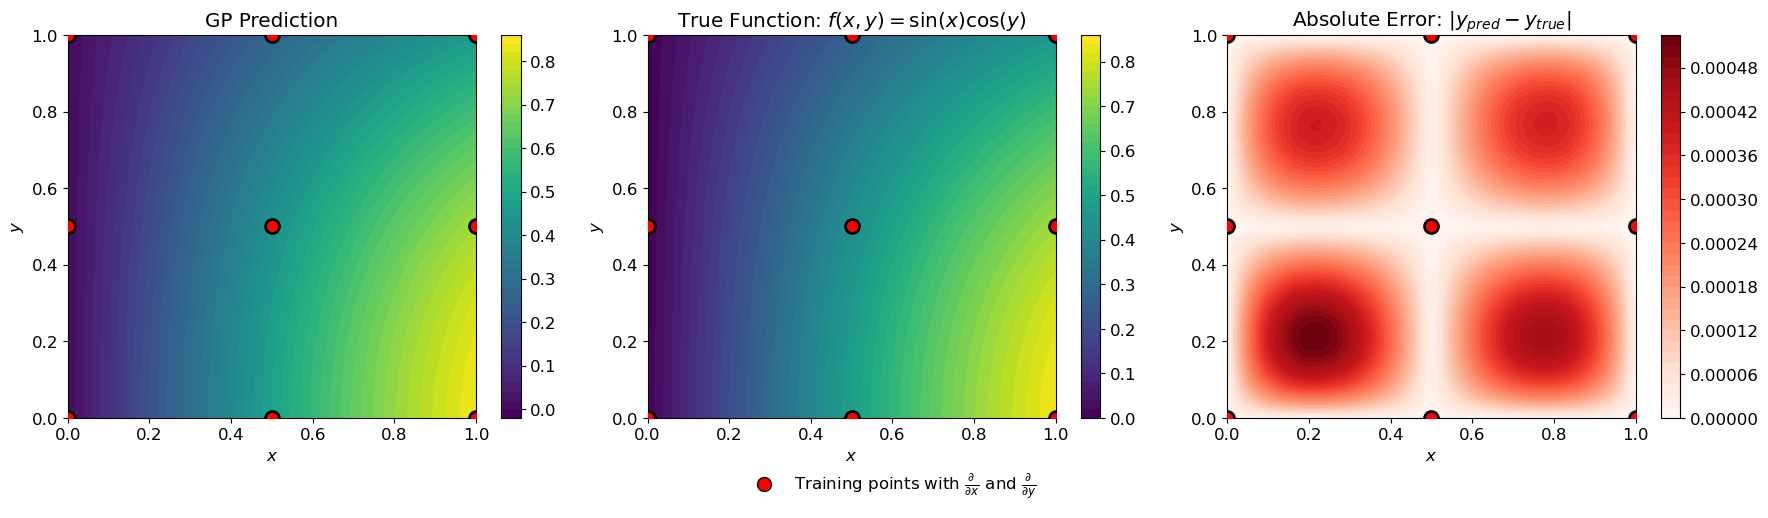

In [4]:
# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Reshape for plotting
y_pred_grid = y_pred.reshape(X1_test.shape)
y_true_grid = y_true.reshape(X1_test.shape)
abs_error_grid = abs_error.reshape(X1_test.shape)

# Plot 1: GP Prediction
c1 = axes[0].contourf(X1_test, X2_test, y_pred_grid, levels=50, cmap='viridis')
axes[0].scatter(X_train[:, 0], X_train[:, 1], c='red', s=100,
                edgecolors='k', linewidths=2, zorder=5)
axes[0].set_xlabel('$x$')
axes[0].set_ylabel('$y$')
axes[0].set_title('GP Prediction')
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])
fig.colorbar(c1, ax=axes[0])

# Plot 2: True Function
c2 = axes[1].contourf(X1_test, X2_test, y_true_grid, levels=50, cmap='viridis')
axes[1].scatter(X_train[:, 0], X_train[:, 1], c='red', s=100,
                edgecolors='k', linewidths=2, zorder=5)
axes[1].set_xlabel('$x$')
axes[1].set_ylabel('$y$')
axes[1].set_title(r'True Function: $f(x, y) = \sin(x)\cos(y)$')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])
fig.colorbar(c2, ax=axes[1])

# Plot 3: Absolute Error
c3 = axes[2].contourf(X1_test, X2_test, abs_error_grid, levels=50, cmap='Reds')
axes[2].scatter(X_train[:, 0], X_train[:, 1], c='red', s=100,
                edgecolors='k', linewidths=2, zorder=5)
axes[2].set_xlabel('$x$')
axes[2].set_ylabel('$y$')
axes[2].set_title(r'Absolute Error: $|y_{pred} - y_{true}|$')
axes[2].set_xlim([0, 1])
axes[2].set_ylim([0, 1])
fig.colorbar(c3, ax=axes[2])

# Add legend at bottom
custom_lines = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
           markeredgecolor='k', markersize=10,
           label=r'Training points with $\frac{\partial}{\partial x}$ and $\frac{\partial}{\partial y}$')
]
fig.legend(handles=custom_lines, loc='lower center', ncol=1,
           frameon=False, fontsize=12, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.show()

In [5]:
import numpy as np
from jetgp.wdegp.wdegp import wdegp
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 12})

# Define test function: f(x) = sin(10*pi*x)/(2*x) + (x-1)^4
def f_fun(x):
    return np.sin(10*np.pi*x)/(2*x) + (x-1)**4

def f1_fun(x):  # First derivative
    return (10*np.pi*np.cos(10*np.pi*x))/(2*x) - \
           np.sin(10*np.pi*x)/(2*x**2) + 4*(x-1)**3

def f2_fun(x):  # Second derivative
    return -(100*np.pi**2*np.sin(10*np.pi*x))/(2*x) - \
           (20*np.pi*np.cos(10*np.pi*x))/(2*x**2) + \
           np.sin(10*np.pi*x)/(x**3) + 12*(x-1)**2

# Generate training points
X_all = np.linspace(0.5, 2.5, 10).reshape(-1, 1)

# Partition into two submodels (alternating points)
submodel1_indices = [0, 2, 4, 6, 8]
submodel2_indices = [1, 3, 5, 7, 9]

# Reorder for contiguous indexing
X_train = np.vstack([X_all[submodel1_indices],
                     X_all[submodel2_indices]])
y_vals = f_fun(X_train.flatten()).reshape(-1, 1)

print("Training data prepared with 2 submodels (5 points each)")

Training data prepared with 2 submodels (5 points each)


In [6]:
# Compute derivatives for each submodel
d1_sm1 = np.array([[f1_fun(X_train[i,0])] for i in range(5)])
d2_sm1 = np.array([[f2_fun(X_train[i,0])] for i in range(5)])
d1_sm2 = np.array([[f1_fun(X_train[i,0])] for i in range(5,10)])
d2_sm2 = np.array([[f2_fun(X_train[i,0])] for i in range(5,10)])

# Package submodel data
submodel_data = [
    [y_vals, d1_sm1, d2_sm1],  # Submodel 1
    [y_vals, d1_sm2, d2_sm2]   # Submodel 2
]

submodel_indices = [[0,1,2,3,4], [5,6,7,8,9]]
derivative_specs = [[[[[1,1]]], [[[1,2]]]], [[[[1,1]]], [[[1,2]]]]]

print("Initializing WDEGP model...")

Initializing WDEGP model...


In [7]:
# Initialize and optimize
model = wdegp(X_train, submodel_data, n_order=2, n_bases=1,
              index=submodel_indices,
              der_indices=derivative_specs,
              normalize=True, kernel="SE",
              kernel_type="anisotropic")

print("Optimizing hyperparameters...")
params = model.optimize_hyperparameters(optimizer='jade',
                                         pop_size=100,
                                         n_generations=15)

print("Optimization complete!")

Optimizing hyperparameters...


Optimization complete!


In [8]:
# Predict
X_test = np.linspace(0.5, 2.5, 250).reshape(-1, 1)
y_pred, y_cov, submodel_preds, submodel_covs = model.predict(X_test, params, calc_cov=True, return_submodels = True)

# Predict individual submodels
y_pred_sm1 = submodel_preds[0].flatten()
y_cov_sm1  = submodel_covs[0].flatten()

y_pred_sm2 = submodel_preds[1].flatten()
y_cov_sm2  = submodel_covs[1].flatten()

# Compute true function
y_true = f_fun(X_test.flatten())

# Compute confidence intervals (95%)
std_global = np.sqrt(y_cov)
std_sm1 = np.sqrt(y_cov_sm1)
std_sm2 = np.sqrt(y_cov_sm2)

print(f"Predictions complete for {len(X_test)} test points")

Predictions complete for 250 test points


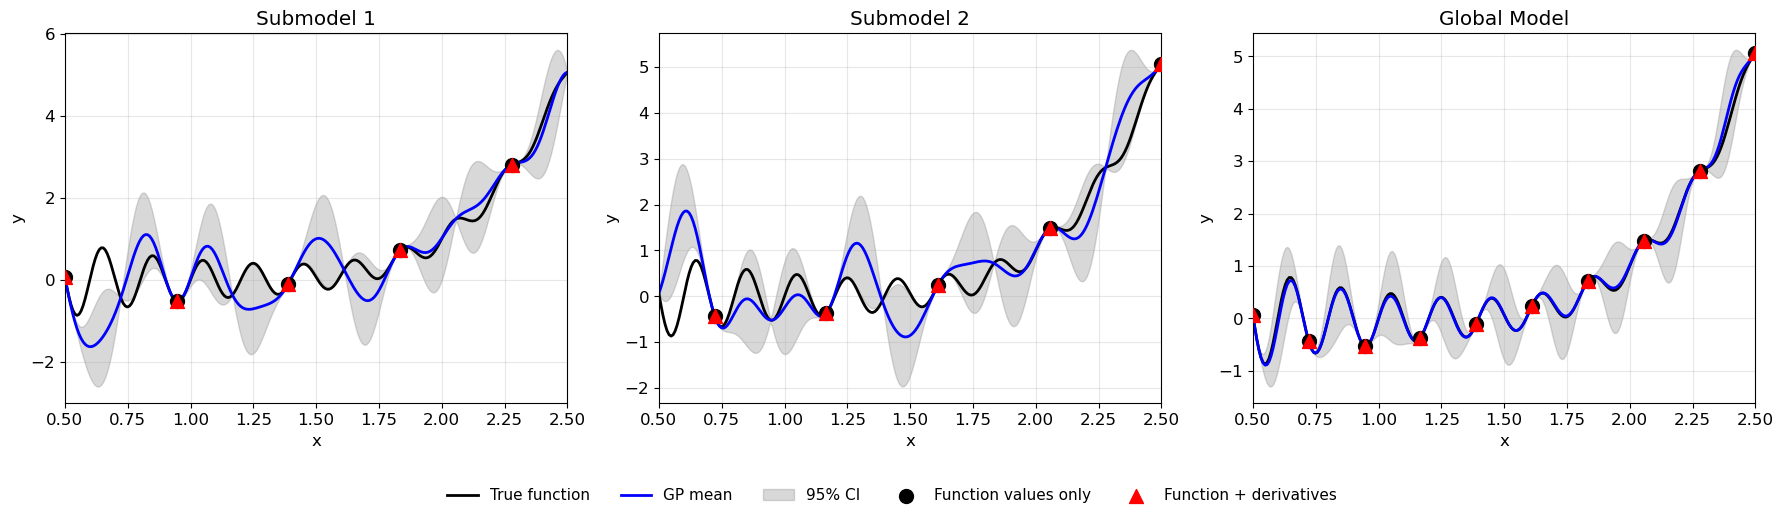

In [9]:
# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Submodel 1
axes[0].plot(X_test, y_true, 'k-', linewidth=2, label='True function')
axes[0].plot(X_test, y_pred_sm1, 'b-', linewidth=2, label='GP mean')
axes[0].fill_between(X_test.flatten(),
                     y_pred_sm1.flatten() - 1.96*std_sm1,
                     y_pred_sm1.flatten() + 1.96*std_sm1,
                     color='gray', alpha=0.3, label='95% CI')
axes[0].scatter(X_train[:5], y_vals[:5], c='black', s=100,
                zorder=5, marker='o', label='Function values only')
axes[0].scatter(X_train[:5], y_vals[:5], c='red', s=100,
                zorder=6, marker='^', label='Function + derivatives')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Submodel 1')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0.5, 2.5])

# Submodel 2
axes[1].plot(X_test, y_true, 'k-', linewidth=2, label='True function')
axes[1].plot(X_test, y_pred_sm2, 'b-', linewidth=2, label='GP mean')
axes[1].fill_between(X_test.flatten(),
                     y_pred_sm2.flatten() - 1.96*std_sm2,
                     y_pred_sm2.flatten() + 1.96*std_sm2,
                     color='gray', alpha=0.3, label='95% CI')
axes[1].scatter(X_train[5:], y_vals[5:], c='black', s=100,
                zorder=5, marker='o')
axes[1].scatter(X_train[5:], y_vals[5:], c='red', s=100,
                zorder=6, marker='^')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title('Submodel 2')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0.5, 2.5])

# Global Model
axes[2].plot(X_test, y_true, 'k-', linewidth=2, label='True function')
axes[2].plot(X_test, y_pred.flatten(), 'b-', linewidth=2, label='GP mean')
axes[2].fill_between(X_test.flatten(),
                     y_pred.flatten() - 1.96*std_global,
                     y_pred.flatten() + 1.96*std_global,
                     color='gray', alpha=0.3, label='95% CI')
axes[2].scatter(X_train[:5], y_vals[:5], c='black', s=100,
                zorder=5, marker='o')
axes[2].scatter(X_train[:5], y_vals[:5], c='red', s=100,
                zorder=6, marker='^')
axes[2].scatter(X_train[5:], y_vals[5:], c='black', s=100,
                zorder=5, marker='o')
axes[2].scatter(X_train[5:], y_vals[5:], c='red', s=100,
                zorder=6, marker='^')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
axes[2].set_title('Global Model')
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim([0.5, 2.5])

# Create legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5,
           frameon=False, fontsize=11, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()